# nGen Log Analysis
Plots **Anode Voltage** and **Anode Current** vs. time (minutes) from a selected nGen CSV log file.

In [1]:
import os
import glob
import pandas as pd
import matplotlib.pyplot as plt
import ipywidgets as widgets
from IPython.display import display

In [10]:
# Discover CSV and activity log files in the Logs folder
logs_dir = os.path.join(os.path.dirname(os.path.abspath('__file__')), 'Logs')
csv_files = sorted(glob.glob(os.path.join(logs_dir, '*.csv')))
txt_files = sorted(glob.glob(os.path.join(logs_dir, '*.txt')))

if not csv_files:
    raise FileNotFoundError(f'No CSV files found in: {logs_dir}')

file_dropdown = widgets.Dropdown(
    options=[(os.path.basename(f), f) for f in csv_files],
    description='CSV log:',
    layout=widgets.Layout(width='60%'),
    style={'description_width': 'initial'}
)
txt_dropdown = widgets.Dropdown(
    options=[('(none)', None)] + [(os.path.basename(f), f) for f in txt_files],
    description='Activity log (.txt):',
    layout=widgets.Layout(width='60%'),
    style={'description_width': 'initial'}
)
display(file_dropdown, txt_dropdown)

Dropdown(description='CSV log:', layout=Layout(width='60%'), options=(('nGen-400 2026-02-25 11.54.40.csv', '/r…

Dropdown(description='Activity log (.txt):', layout=Layout(width='60%'), options=(('(none)', None), ('nGen-400…

In [24]:
import re

# 'key' is the display name used for filtering; '{}' in label is replaced by regex capture
EVENT_SPECS = [
    {'pattern': r'Going from state "Off" to "On"',                     'key': 'ON',           'label': 'ON',        'color': 'red',    'dash': 'solid',  'lw': 1.2},
    {'pattern': r'Going from state "On" to "Off"',                     'key': 'OFF',          'label': 'OFF',       'color': 'red',    'dash': 'dashed', 'lw': 1.2},
    {'pattern': r"Received request for '\(1\)Fault' from 'Interlock'", 'key': 'Interlock',    'label': 'Interlock', 'color': 'orange', 'dash': 'dashed', 'lw': 1.2},
    {'pattern': r'Gas Pressure set to (\d+\.\d{3})',                   'key': 'Gas Pressure', 'label': 'P = {}',    'color': 'blue',   'dash': 'solid',  'lw': 0.8},
    {'pattern': r'RF Frequency set to (\d+\.\d{2})',                   'key': 'RF Frequency', 'label': 'RF = {}',   'color': 'green',  'dash': 'solid',  'lw': 0.8},
    {'pattern': r'Accelerating Voltage set to (\d+(?:\.\d+)?)',    'key': 'Accel Voltage', 'label': 'V = {} kV', 'color': 'magenta', 'dash': 'solid', 'lw': 0.8},
]

def parse_events(txt_path, df):
    """Return list of event dicts from the activity log."""
    events = []
    if not txt_path:
        return events
    # Parse CSV Time column (e.g. '3/10/2026  10:37:26 AM') into total seconds since midnight
    csv_times = pd.to_datetime(df['Time'], format='mixed')
    csv_secs = csv_times.dt.hour * 3600 + csv_times.dt.minute * 60 + csv_times.dt.second
    with open(txt_path, 'r') as f:
        for line in f:
            # Outer timestamp HH:MM:SS.mmm (24h)
            m_ts = re.match(r'^(\d{2}):(\d{2}):(\d{2})\.\d+', line)
            if not m_ts:
                continue
            for spec in EVENT_SPECS:
                m = re.search(spec['pattern'], line)
                if m:
                    log_secs = int(m_ts.group(1))*3600 + int(m_ts.group(2))*60 + int(m_ts.group(3))
                    # Find CSV row whose wall-clock second is closest to the log timestamp
                    idx = (csv_secs - log_secs).abs().idxmin()
                    lbl = spec['label'].format(m.group(1)) if '{}' in spec['label'] else spec['label']
                    events.append({
                        'time_min': df.at[idx, 'Elapsed (s)'] / 60.0,
                        'key':   spec['key'],
                        'label': lbl,
                        'color': spec['color'],
                        'dash':  spec['dash'],
                        'lw':    spec['lw'],
                    })
    return events

# Load CSV
df = pd.read_csv(file_dropdown.value)
df['Time (min)'] = df['Elapsed (s)'] / 60.0

# Parse all events
events = parse_events(txt_dropdown.value, df)

# Count events per type for display
from collections import Counter
counts = Counter(ev['key'] for ev in events)

# Build checkboxes — one per event type, all ticked by default
all_keys = [spec['key'] for spec in EVENT_SPECS]
event_checkboxes = {
    key: widgets.Checkbox(
        value=True,
        description=f"{key} ({counts.get(key, 0)})",
        style={'description_width': 'initial'},
        layout=widgets.Layout(width='220px')
    )
    for key in all_keys
}

print('Select which events to show, then re-run the plot cells:')
display(widgets.HBox(list(event_checkboxes.values())))

Select which events to show, then re-run the plot cells:


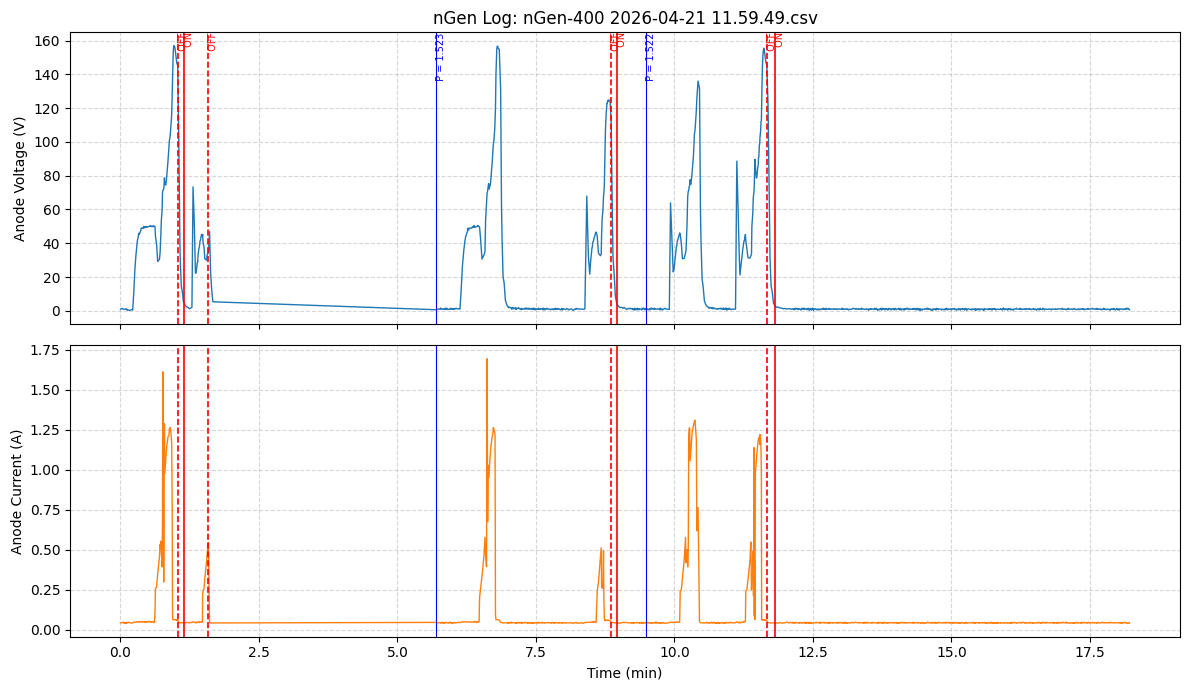

In [25]:
# ── Fixed plot ────────────────────────────────────────────────────────────────
active_events = [ev for ev in events if event_checkboxes[ev['key']].value]

fig_static, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 7), sharex=True)

ax1.plot(df['Time (min)'], df['Anode Voltage'], color='tab:blue', linewidth=1)
ax1.set_ylabel('Anode Voltage (V)')
ax1.set_title(f'nGen Log: {os.path.basename(file_dropdown.value)}')
ax1.grid(True, linestyle='--', alpha=0.5)

ax2.plot(df['Time (min)'], df['Anode Current'], color='tab:orange', linewidth=1)
ax2.set_ylabel('Anode Current (A)')
ax2.set_xlabel('Time (min)')
ax2.grid(True, linestyle='--', alpha=0.5)

_mpl_ls = {'solid': '-', 'dashed': '--'}
for ev in active_events:
    ls = _mpl_ls[ev['dash']]
    ax1.axvline(ev['time_min'], color=ev['color'], linewidth=ev['lw'], linestyle=ls)
    ax1.text(ev['time_min'], ax1.get_ylim()[1], f" {ev['label']}", color=ev['color'],
             fontsize=7, va='top', ha='left', clip_on=True, rotation=90)
    ax2.axvline(ev['time_min'], color=ev['color'], linewidth=ev['lw'], linestyle=ls)

fig_static.tight_layout()
plt.show()


In [26]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# Width of the visible window in minutes — adjust to zoom in/out
window_min = 5

fig = make_subplots(
    rows=2, cols=1,
    shared_xaxes=True,
    subplot_titles=('Anode Voltage', 'Anode Current'),
    vertical_spacing=0.27
)

fig.add_trace(
    go.Scatter(x=df['Time (min)'], y=df['Anode Voltage'],
               mode='lines', name='Anode Voltage',
               line=dict(color='steelblue', width=1)),
    row=1, col=1
)
fig.add_trace(
    go.Scatter(x=df['Time (min)'], y=df['Anode Current'],
               mode='lines', name='Anode Current',
               line=dict(color='darkorange', width=1)),
    row=2, col=1
)

_plotly_dash = {'solid': 'solid', 'dashed': 'dash'}

active_events = [ev for ev in events if event_checkboxes[ev['key']].value]

for ev in active_events:
    pd_dash = _plotly_dash[ev['dash']]
    line_style = dict(color=ev['color'], width=ev['lw'], dash=pd_dash)
    # Top subplot line + label
    fig.add_shape(type='line', x0=ev['time_min'], x1=ev['time_min'], y0=0, y1=1,
                  xref='x', yref='y domain',
                  line=line_style, row=1, col=1)
    fig.add_annotation(x=ev['time_min'], y=1, xref='x', yref='y domain',
                       text=ev['label'], showarrow=False,
                       font=dict(color=ev['color'], size=12),
                       xanchor='left', yanchor='top',
                       textangle=-90, row=1, col=1)
    # Bottom subplot line only
    fig.add_shape(type='line', x0=ev['time_min'], x1=ev['time_min'], y0=0, y1=1,
                  xref='x2', yref='y2 domain',
                  line=line_style, row=2, col=1)

t_min = df['Time (min)'].min()

fig.update_layout(
    title=f'nGen Log (scrollable): {os.path.basename(file_dropdown.value)}',
    height=1000,
    xaxis=dict(
        range=[t_min, t_min + window_min],
        rangeslider=dict(visible=True, thickness=0.06),
        title='Time (min)'
    ),
    xaxis2=dict(
        range=[t_min, t_min + window_min],
        title='Time (min)'
    ),
    yaxis=dict(title='Voltage (V)'),
    yaxis2=dict(title='Current (A)'),
    showlegend=False
)

fig.show()


In [27]:
# Scrollable plot — event lines only, no text annotations
fig_clean = make_subplots(
    rows=2, cols=1,
    shared_xaxes=True,
    subplot_titles=('Anode Voltage', 'Anode Current'),
    vertical_spacing=0.27
)

fig_clean.add_trace(
    go.Scatter(x=df['Time (min)'], y=df['Anode Voltage'],
               mode='lines', name='Anode Voltage',
               line=dict(color='steelblue', width=1)),
    row=1, col=1
)
fig_clean.add_trace(
    go.Scatter(x=df['Time (min)'], y=df['Anode Current'],
               mode='lines', name='Anode Current',
               line=dict(color='darkorange', width=1)),
    row=2, col=1
)

fig_clean.update_layout(
    title=f'nGen Log (scrollable, no labels): {os.path.basename(file_dropdown.value)}',
    height=1000,
    xaxis=dict(
        range=[t_min, t_min + window_min],
        rangeslider=dict(visible=True, thickness=0.06),
        title='Time (min)'
    ),
    xaxis2=dict(
        range=[t_min, t_min + window_min],
        title='Time (min)'
    ),
    yaxis=dict(title='Voltage (V)'),
    yaxis2=dict(title='Current (A)'),
    showlegend=False
)

fig_clean.show()


In [28]:
# Export both scrollable plots as standalone HTML files
outputs_dir = os.path.join(os.path.dirname(os.path.abspath('__file__')), 'Outputs')
os.makedirs(outputs_dir, exist_ok=True)

log_stem = os.path.splitext(os.path.basename(file_dropdown.value))[0]

path_annotated = os.path.join(outputs_dir, f'{log_stem}_scrollable_annotated.html')
fig.write_html(path_annotated, include_plotlyjs='cdn')
print(f'Saved (annotated): {path_annotated}')

path_clean = os.path.join(outputs_dir, f'{log_stem}_scrollable_clean.html')
fig_clean.write_html(path_clean, include_plotlyjs='cdn')
print(f'Saved (clean):     {path_clean}')


Saved (annotated): /root/nGen-log-analysis/Outputs/nGen-400 2026-04-21 11.59.49_scrollable_annotated.html
Saved (clean):     /root/nGen-log-analysis/Outputs/nGen-400 2026-04-21 11.59.49_scrollable_clean.html
